Supervised Learning on Census Income - 5/29/2026 - aprtay2887

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

data = pd.read_csv(r"C:\Users\ecpi\Documents\census_income_dataset.csv")

print(data.info())
print(data.describe())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  4

In [3]:
data = data.replace('?', np.nan)

data = data.dropna()

data = data.drop_duplicates()

print("Shape after cleaning:", data.shape)

Shape after cleaning: (45194, 15)


In [4]:
data['income'] = data['income'].apply(lambda x: 1 if x == '>50K' else 0)
data = pd.get_dummies(data, drop_first=True)

print("Shape after encoding:", data.shape)

Shape after encoding: (45194, 97)


In [5]:
X = data.drop('income', axis=1)
Y = data['income']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

Y_pred = knn.predict(X_test)
print(Y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [8]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8243970794306364
Precision: 0.4529968454258675
Recall: 0.3216845878136201
F1 Score: 0.37621168456903326
Confusion Matrix:
 [[10460   867]
 [ 1514   718]]


In [9]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3)
grid.fit(X_train, Y_train)

print("Best Params:", grid.best_params_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [10]:
best_knn = grid.best_estimator_
Y_pred_tuned = best_knn.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred_tuned))
print("Precision:", precision_score(Y_test, Y_pred_tuned))
print("Recall:", recall_score(Y_test, Y_pred_tuned))
print("F1 Score:",  f1_score(Y_test, Y_pred_tuned))

cm_tuned = confusion_matrix(Y_test, Y_pred_tuned)
print("Confusion Matrix:\n", cm_tuned)

Accuracy: 0.8345748211520023
Precision: 0.49591078066914496
Recall: 0.29883512544802865
F1 Score: 0.3729382163824434
Confusion Matrix:
 [[10649   678]
 [ 1565   667]]


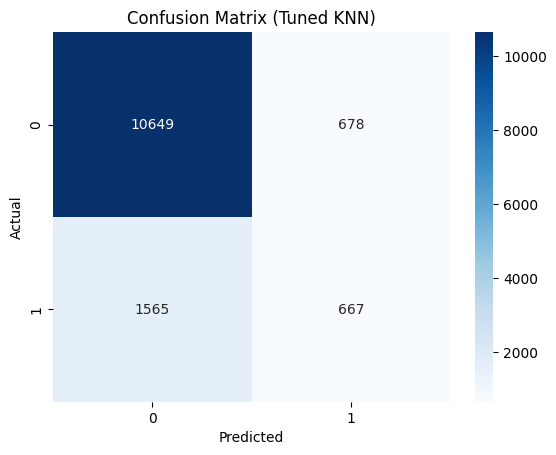

In [11]:
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

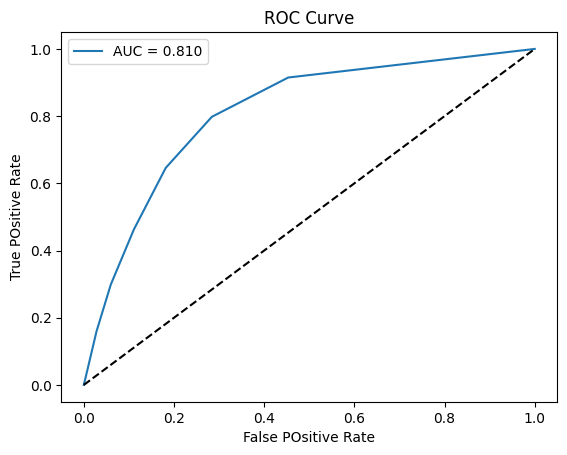

AUC Score: 0.8104676933631159


In [14]:
Y_proba = best_knn.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(Y_test, Y_proba)
auc = roc_auc_score(Y_test, Y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], color='black', linestyle='--')
plt.xlabel("False POsitive Rate")
plt.ylabel("True POsitive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc)

The baseline model performs well overall within an accuracy above 82%. The recall, however is low at around 32% which shows the model did struggle to identify individuals earning more than 50K. I assume this would be because the dataset is imbalanced and the KNN is sensitive to class density. After, tuning, accuracy, and precision did improve. The model was more conservative in predicting the greater than 50K income, helping in reducing false positives greatly. The recall did decrease only slightly but the overall performance is more balanced and stable. The ROC curve shows an AUC of 0.81, which indicates good discrimination ability.

The GridSearchCV selected n_neighbors = 9, weights = 'uniform' and metric = 'manhattan' as the most optimal parameters. These improvd accuracy and precision while also reducing false positives. The tuned model demonstrated better overall stability and discrimination ability which was reflected in the AUC score of 0.81.